In [1]:
%pip install -q opencv-python-headless scikit-image scikit-learn datasets Pillow tqdm seaborn hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import warnings
import logging
import getpass

# Must be set before huggingface_hub / datasets are imported
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_VERBOSITY']           = 'error'

warnings.filterwarnings('ignore')
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

def _setup_hf_token():
    # 1. environment variable
    token = os.environ.get('HF_TOKEN')

    # 2. Colab Secrets
    if not token:
        try:
            from google.colab import userdata
            token = userdata.get('HF_TOKEN')
        except Exception:
            pass

    # 3. manual prompt
    if not token:
        print("No HF_TOKEN found in environment or Colab Secrets.")
        try:
            entered = getpass.getpass("  Paste your HF token (or press Enter to skip): ").strip()
            if entered:
                token = entered
        except Exception:
            pass

    if token:
        os.environ['HF_TOKEN'] = token
        try:
            from huggingface_hub import login
            login(token=token, add_to_git_credential=False)
            print("HF Hub: authenticated ✓")
        except Exception:
            pass
    else:
        print("HF Hub: continuing anonymously (rate-limited).")

_setup_hf_token()

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from PIL import Image
import datasets as _ds_lib
_ds_lib.logging.set_verbosity_error()

from datasets import load_dataset
from skimage.feature import hog
from skimage import exposure

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from tqdm.auto import tqdm

print(f"OpenCV : {cv2.__version__}")
print(f"NumPy  : {np.__version__}")

CONFIG = {
    'dataset_id'  : 'marcelarosalesj/inria-person',
    'test_size'   : 0.20,
    'random_seed' : 42,
    'window_size' : (128, 64),   # H × W — standard Dalal & Triggs window
    'hog': {
        'orientations'   : 9,
        'pixels_per_cell': (8, 8),
        'cells_per_block': (2, 2),
        'block_norm'     : 'L2-Hys',
        'transform_sqrt' : True,
    },
    # LinearSVC is the canonical classifier for HOG features (Dalal & Triggs 2005)
    'svm_C'           : 0.01,
    'augment_flip'    : True,
    'hard_neg_rounds' : 1,
    'model_path'      : 'hog_svm_model.pkl',
    'scaler_path'     : 'hog_svm_scaler.pkl',
}

print("\nConfiguration:")
for k, v in CONFIG.items():
    print(f"  {k:<22} : {v}")

No HF_TOKEN found in environment or Colab Secrets.
HF Hub: authenticated ✓
OpenCV : 4.13.0
NumPy  : 2.0.2

Configuration:
  dataset_id             : marcelarosalesj/inria-person
  test_size              : 0.2
  random_seed            : 42
  window_size            : (128, 64)
  hog                    : {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys', 'transform_sqrt': True}
  svm_C                  : 0.01
  augment_flip           : True
  hard_neg_rounds        : 1
  model_path             : hog_svm_model.pkl
  scaler_path            : hog_svm_scaler.pkl


In [3]:
def compute_hog(image: np.ndarray, visualize: bool = False):
    H, W = CONFIG['window_size']
    resized = cv2.resize(image, (W, H))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY) if resized.ndim == 3 else resized
    return hog(gray, visualize=visualize, **CONFIG['hog'])

dummy    = np.zeros((*CONFIG['window_size'], 3), dtype=np.uint8)
FEAT_LEN = len(compute_hog(dummy))
print(f"HOG descriptor length: {FEAT_LEN} dims")

HOG descriptor length: 3780 dims


Resolving data files:   0%|          | 0/2487 [00:00<?, ?it/s]

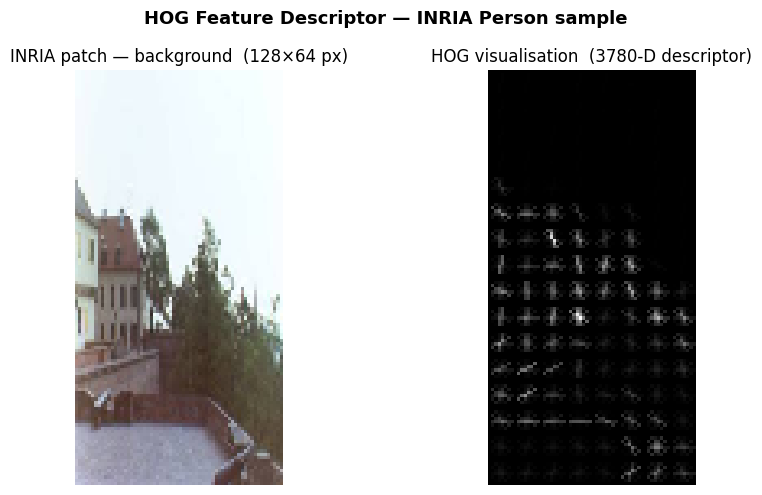

In [4]:
ds_preview = load_dataset(CONFIG['dataset_id'], split='train[:3]')

sample = next((ex for ex in ds_preview if ex['label'] == 1), ds_preview[0])
sample_bgr = cv2.cvtColor(np.array(sample['image'].convert('RGB')), cv2.COLOR_RGB2BGR)

H, W       = CONFIG['window_size']
patch      = cv2.resize(sample_bgr, (W, H))
patch_gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

feats, hog_img = hog(patch_gray, **CONFIG['hog'], visualize=True)
hog_img        = exposure.rescale_intensity(hog_img, in_range=(0, 10))

label_str = 'pedestrian' if sample['label'] == 1 else 'background'

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"INRIA patch — {label_str}  ({H}×{W} px)")
axes[0].axis('off')
axes[1].imshow(hog_img, cmap='gray')
axes[1].set_title(f"HOG visualisation  ({FEAT_LEN}-D descriptor)")
axes[1].axis('off')
plt.suptitle("HOG Feature Descriptor — INRIA Person sample", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
import io, sys, contextlib

print(f"Loading '{CONFIG['dataset_id']}' …")

# Suppress HF's per-shard download bars; show a single spinner instead
_ds_lib.disable_progress_bar()
with tqdm(total=1, desc='Downloading / loading from cache', unit='dataset',
          bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    with contextlib.redirect_stderr(io.StringIO()):   # swallow remaining stderr noise
        ds = load_dataset(CONFIG['dataset_id'], split='train')
    pbar.update(1)
_ds_lib.enable_progress_bar()

print(f"Total samples : {len(ds)}")

try:
    label_names = ds.features['label'].names
except Exception:
    label_names = ['background', 'pedestrian']

print(f"Label names   : {dict(enumerate(label_names))}")
counts = np.bincount([ex['label'] for ex in ds])
for i, (name, cnt) in enumerate(zip(label_names, counts)):
    print(f"  {i}  {name:<20}  {cnt}")


def pil_to_bgr(pil_img) -> np.ndarray:
    return cv2.cvtColor(np.array(pil_img.convert('RGB')), cv2.COLOR_RGB2BGR)


def extract_hog_features(dataset) -> tuple:
    """Compute HOG descriptor for every sample; horizontally flip positives for augmentation."""
    X, y = [], []
    for ex in tqdm(dataset, desc='Computing HOG', unit='img'):
        img = pil_to_bgr(ex['image'])
        X.append(compute_hog(img))
        y.append(ex['label'])

        if CONFIG['augment_flip'] and ex['label'] == 1:
            X.append(compute_hog(cv2.flip(img, 1)))
            y.append(1)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("\nExtracting HOG features …")
X_all, y_all = extract_hog_features(ds)

n_pos = int((y_all == 1).sum())
n_neg = int((y_all == 0).sum())
print(f"\nFeature matrix : {X_all.shape}")
print(f"Positives      : {n_pos}   Negatives : {n_neg}")

Loading 'marcelarosalesj/inria-person' …


Total samples : 2487
Label names   : {0: 'no_pedestrians', 1: 'pedestrians'}
  0  no_pedestrians        1218
  1  pedestrians           1269

Extracting HOG features …


Computing HOG:   0%|          | 0/2487 [00:00<?, ?img/s]


Feature matrix : (3756, 3780)
Positives      : 2538   Negatives : 1218


In [6]:
idx = np.arange(len(X_all))
train_idx, test_idx = train_test_split(
    idx, test_size=CONFIG['test_size'],
    random_state=CONFIG['random_seed'], stratify=y_all,
)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

print(f"Train : {len(X_train):5d}  (pos={int(y_train.sum())}, neg={int((y_train==0).sum())})")
print(f"Test  : {len(X_test):5d}  (pos={int(y_test.sum())}, neg={int((y_test==0).sum())})")
print(f"Dims  : {X_train.shape[1]}")

Train :  3004  (pos=2030, neg=974)
Test  :   752  (pos=508, neg=244)
Dims  : 3780


In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

def build_classifier(C: float) -> CalibratedClassifierCV:
    """Wrap LinearSVC in a calibrated classifier to obtain predict_proba."""
    return CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=5000, random_state=CONFIG['random_seed']),
        cv=3, method='sigmoid',
    )

print("Round 0 — initial training …")
model = build_classifier(CONFIG['svm_C'])
model.fit(X_train_s, y_train)

acc0 = accuracy_score(y_train, model.predict(X_train_s))
print(f"  Train accuracy : {acc0:.4f}")

# Hard-negative mining: negatives the model scores > 0.5 are misclassified as positive.
# Re-adding them and retraining significantly reduces false positives.
neg_mask = y_train == 0
for rnd in range(1, CONFIG['hard_neg_rounds'] + 1):
    scores_neg = model.predict_proba(X_train_s[neg_mask])[:, 1]
    hard_mask  = scores_neg > 0.5
    n_hard     = int(hard_mask.sum())

    if n_hard == 0:
        print(f"Round {rnd} — no hard negatives found; stopping early.")
        break

    print(f"Round {rnd} — {n_hard} hard negatives found; retraining …")

    hard_X = X_train_s[neg_mask][hard_mask]
    hard_y = np.zeros(n_hard, dtype=np.int32)

    X_aug = np.vstack([X_train_s, hard_X])
    y_aug = np.concatenate([y_train, hard_y])

    model = build_classifier(CONFIG['svm_C'])
    model.fit(X_aug, y_aug)

    acc_r = accuracy_score(y_aug, model.predict(X_aug))
    print(f"  Train accuracy (augmented) : {acc_r:.4f}")

with open(CONFIG['model_path'],  'wb') as f: pickle.dump(model,  f)
with open(CONFIG['scaler_path'], 'wb') as f: pickle.dump(scaler, f)
print(f"\nModel  → {CONFIG['model_path']}")
print(f"Scaler → {CONFIG['scaler_path']}")

Round 0 — initial training …
  Train accuracy : 1.0000
Round 1 — no hard negatives found; stopping early.

Model  → hog_svm_model.pkl
Scaler → hog_svm_scaler.pkl


In [9]:
y_pred       = model.predict(X_test_s)
y_pred_proba = model.predict_proba(X_test_s)[:, 1]

acc     = accuracy_score (y_test, y_pred)
prec    = precision_score(y_test, y_pred, zero_division=0)
rec     = recall_score   (y_test, y_pred, zero_division=0)
f1      = f1_score       (y_test, y_pred, zero_division=0)
cm      = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"Accuracy  : {acc :.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec :.4f}")
print(f"F1-Score  : {f1  :.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Accuracy  : 0.9827
Precision : 0.9862
Recall    : 0.9882
F1-Score  : 0.9872
ROC-AUC   : 0.9965

                precision    recall  f1-score   support

no_pedestrians       0.98      0.97      0.97       244
   pedestrians       0.99      0.99      0.99       508

      accuracy                           0.98       752
     macro avg       0.98      0.98      0.98       752
  weighted avg       0.98      0.98      0.98       752



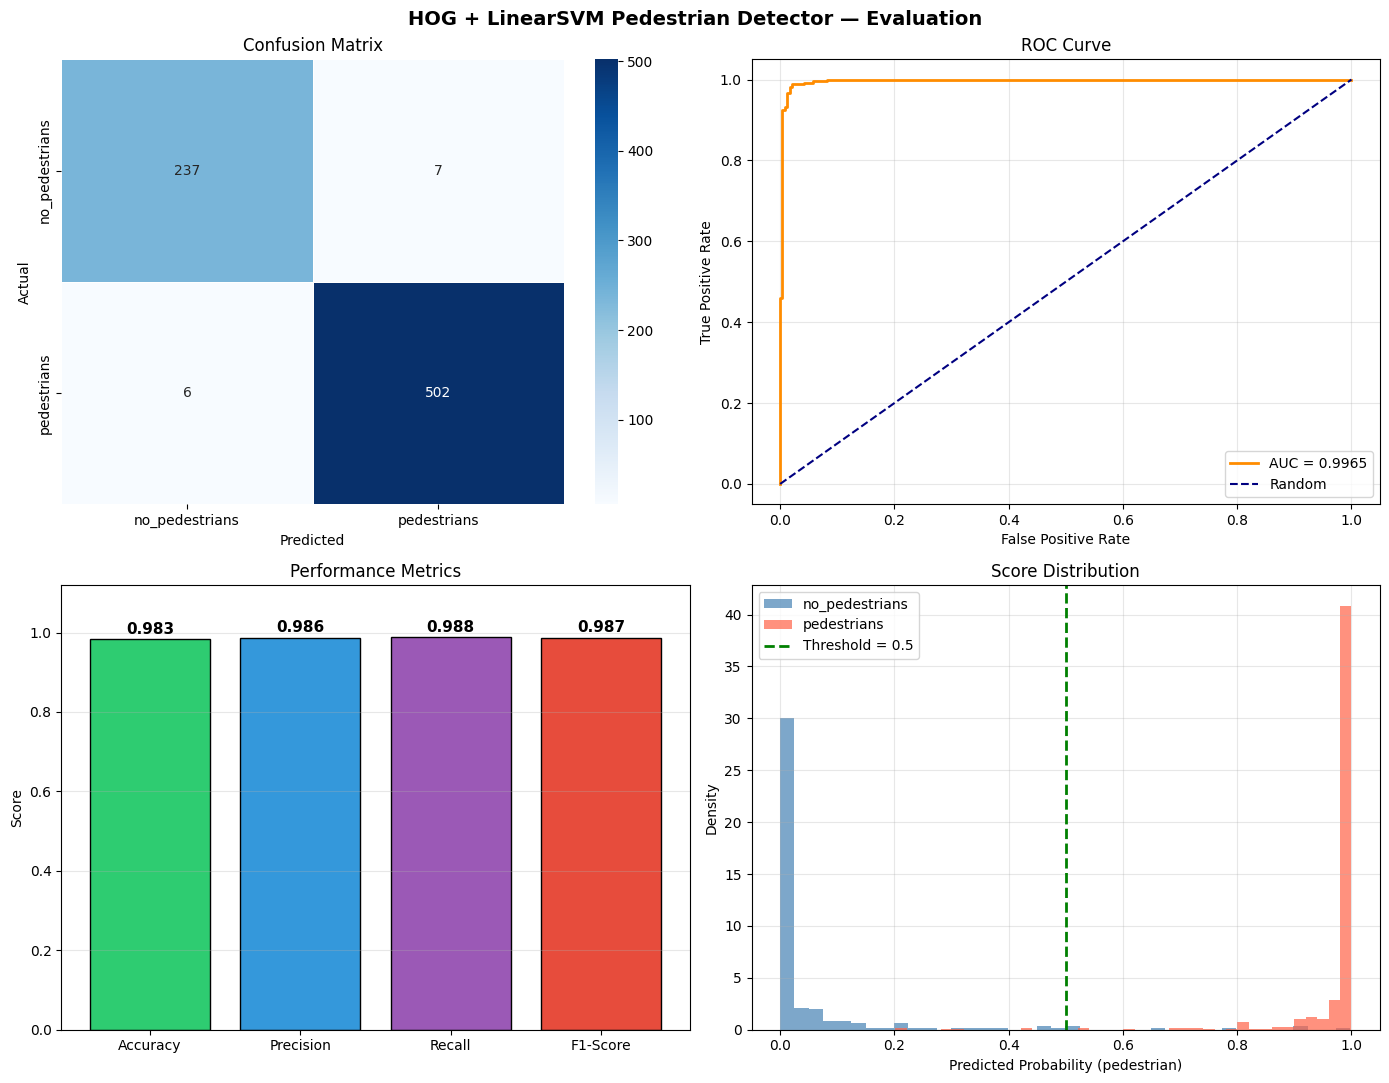

Saved → hog_svm_results.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Confusion matrix
ax = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=label_names, yticklabels=label_names, linewidths=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

# ROC curve
ax = axes[0, 1]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)

# Metric bar chart
ax = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values  = [acc, prec, rec, f1]
colors  = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars    = ax.bar(metrics, values, color=colors, edgecolor='black')
ax.set_ylim(0, 1.12); ax.set_ylabel('Score'); ax.set_title('Performance Metrics')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    ax.annotate(f'{val:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold')

# Score distribution
ax = axes[1, 1]
ax.hist(y_pred_proba[y_test == 0], bins=40, alpha=0.7, label=label_names[0],
        color='steelblue', density=True)
ax.hist(y_pred_proba[y_test == 1], bins=40, alpha=0.7, label=label_names[1],
        color='tomato', density=True)
ax.axvline(0.5, color='green', linestyle='--', lw=2, label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability (pedestrian)')
ax.set_ylabel('Density'); ax.set_title('Score Distribution'); ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('HOG + LinearSVM Pedestrian Detector — Evaluation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hog_svm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → hog_svm_results.png")

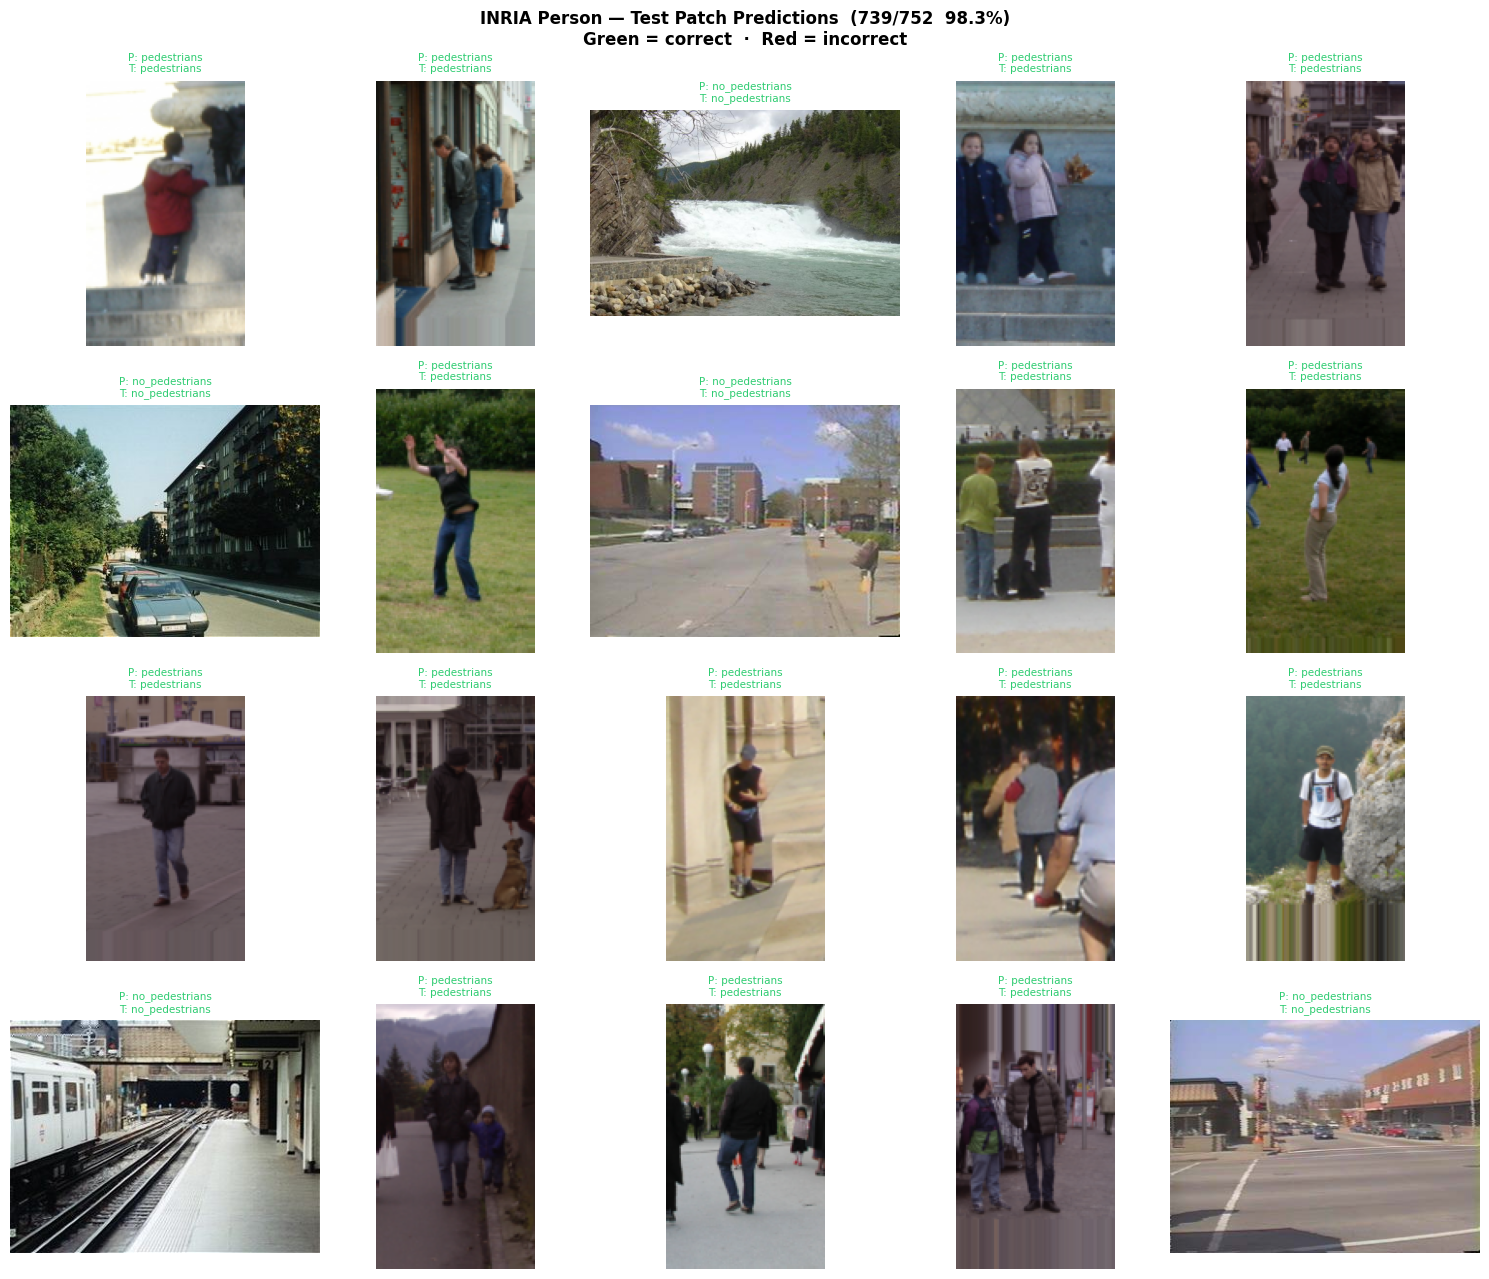

Saved → hog_svm_predictions.png


In [11]:
np.random.seed(CONFIG['random_seed'])

predictions = model.predict(X_test_s)
n_show      = 20
show_idx    = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 13))

for plot_i, local_i in enumerate(show_idx):
    ax      = axes[plot_i // 5, plot_i % 5]
    ds_i    = int(test_idx[local_i])

    # Retrieve original dataset index, accounting for augmented indices
    # augmented positives are interleaved; map back to the original ds row
    orig_ds_indices = []
    for ex_i, ex in enumerate(ds):
        orig_ds_indices.append(ex_i)
        if CONFIG['augment_flip'] and ex['label'] == 1:
            orig_ds_indices.append(ex_i)   # flipped duplicate maps to same source

    src_i   = orig_ds_indices[ds_i] if ds_i < len(orig_ds_indices) else ds_i % len(ds)
    img_rgb = np.array(ds[src_i]['image'].convert('RGB'))

    pred       = int(predictions[local_i])
    truth      = int(y_test[local_i])
    pred_name  = label_names[pred]  if pred  < len(label_names) else str(pred)
    truth_name = label_names[truth] if truth < len(label_names) else str(truth)
    correct    = pred == truth

    ax.imshow(img_rgb)
    ax.set_title(f"P: {pred_name}\nT: {truth_name}", fontsize=7.5,
                 color='#2ecc71' if correct else '#e74c3c')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#2ecc71' if correct else '#e74c3c')
        spine.set_linewidth(4)

n_correct = int((predictions == y_test).sum())
n_total   = len(y_test)

plt.suptitle(
    f"INRIA Person — Test Patch Predictions  "
    f"({n_correct}/{n_total}  {100*n_correct/n_total:.1f}%)\n"
    f"Green = correct  ·  Red = incorrect",
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.savefig('hog_svm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → hog_svm_predictions.png")

Running sliding-window detector on mosaic …


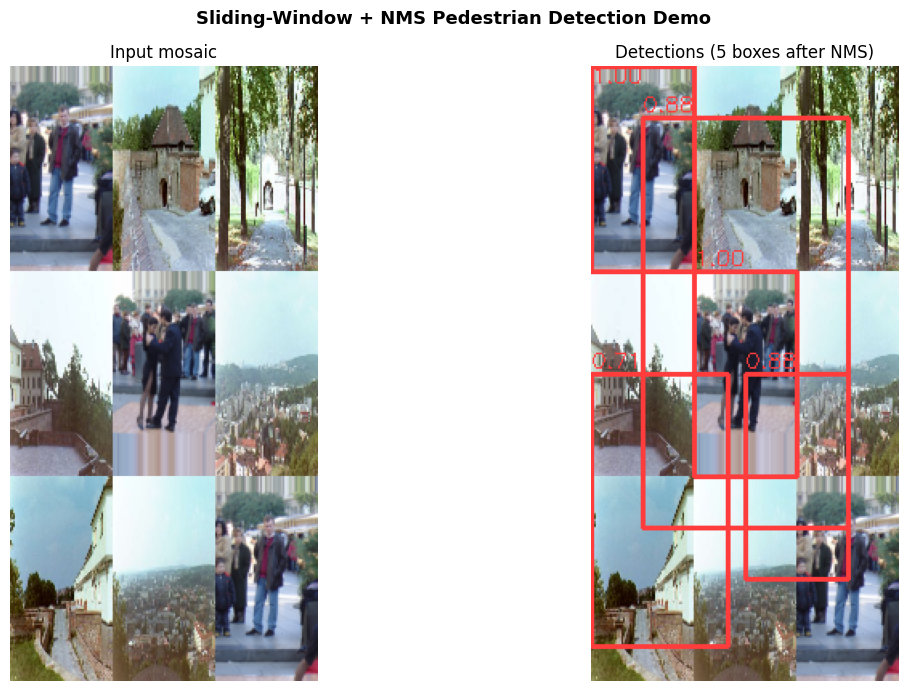

Saved → hog_svm_sliding_window.png  |  5 pedestrian(s) detected


In [12]:
def non_max_suppression(boxes: np.ndarray, scores: np.ndarray,
                        overlap_thresh: float = 0.35) -> list:
    """Greedy NMS — keep highest-scoring box when IoU > threshold."""
    if len(boxes) == 0:
        return []
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort()[::-1]
    keep  = []
    while order.size:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        iou = (np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)) / areas[order[1:]]
        order = order[np.where(iou <= overlap_thresh)[0] + 1]
    return keep


def sliding_window_detect(image_bgr: np.ndarray, clf, sc,
                           win_h=128, win_w=64,
                           step=16, scales=(1.0, 0.75, 0.5),
                           threshold=0.6) -> list:
    """Multi-scale sliding window pedestrian detector."""
    all_boxes, all_scores = [], []
    for scale in scales:
        img = cv2.resize(image_bgr,
                         (int(image_bgr.shape[1] * scale),
                          int(image_bgr.shape[0] * scale)))
        if img.shape[0] < win_h or img.shape[1] < win_w:
            continue
        for y in range(0, img.shape[0] - win_h, step):
            for x in range(0, img.shape[1] - win_w, step):
                patch   = img[y:y + win_h, x:x + win_w]
                feat    = sc.transform([compute_hog(patch)])
                prob    = clf.predict_proba(feat)[0, 1]
                if prob >= threshold:
                    all_boxes.append([int(x / scale), int(y / scale),
                                      int((x + win_w) / scale),
                                      int((y + win_h) / scale)])
                    all_scores.append(prob)

    if not all_boxes:
        return []

    boxes  = np.array(all_boxes)
    scores = np.array(all_scores)
    keep   = non_max_suppression(boxes, scores)
    return [(boxes[i], scores[i]) for i in keep]


# Pull a few background (negative) patches and stitch them into a synthetic scene
# for a visual sliding-window demo (no full INRIA images available via HF split).
np.random.seed(42)
neg_indices = np.where(y_all == 0)[0][:6]
pos_indices = np.where(y_all == 1)[0][:3]
chosen      = np.concatenate([neg_indices, pos_indices])
np.random.shuffle(chosen)

# Build a 3×3 mosaic canvas from dataset patches
canvas_rows, canvas_cols = 3, 3
H, W                     = CONFIG['window_size']
canvas = np.zeros((H * canvas_rows, W * canvas_cols, 3), dtype=np.uint8)

for idx_c, ds_i in enumerate(chosen[:canvas_rows * canvas_cols]):
    # Map back to original dataset index (accounting for augmentation)
    src = orig_ds_indices[int(ds_i)] if int(ds_i) < len(orig_ds_indices) else int(ds_i) % len(ds)
    img_bgr = pil_to_bgr(ds[src]['image'])
    img_bgr = cv2.resize(img_bgr, (W, H))
    r, c    = divmod(idx_c, canvas_cols)
    canvas[r * H:(r + 1) * H, c * W:(c + 1) * W] = img_bgr

print("Running sliding-window detector on mosaic …")
detections = sliding_window_detect(canvas, model, scaler, threshold=0.65)

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
result     = canvas_rgb.copy()
for box, score in detections:
    x1, y1, x2, y2 = box
    cv2.rectangle(result, (x1, y1), (x2, y2), (255, 60, 60), 2)
    cv2.putText(result, f'{score:.2f}', (x1, max(y1 - 4, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 60, 60), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(canvas_rgb);  axes[0].set_title('Input mosaic');      axes[0].axis('off')
axes[1].imshow(result);      axes[1].set_title(f'Detections ({len(detections)} boxes after NMS)')
axes[1].axis('off')
plt.suptitle('Sliding-Window + NMS Pedestrian Detection Demo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hog_svm_sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → hog_svm_sliding_window.png  |  {len(detections)} pedestrian(s) detected")